# Assignment 05 — Vegetation Index (NDVI) Calculation and Crop Health Analysis

**Objective:** Calculate the Normalized Difference Vegetation Index (NDVI) for 20 Ohio Maumee watershed fields using satellite imagery, analyze crop health patterns across fields and growing seasons, and identify relationships between NDVI, crop type, and environmental variables.

**Key tasks:**
1. Acquire multispectral satellite imagery (NIR and Red bands) for the study fields
2. Calculate NDVI: `(NIR - Red) / (NIR + Red)`
3. Analyze NDVI distribution and temporal trends across fields
4. Compare crop health by crop type and soil properties
5. Visualize NDVI maps and time series

**Data sources:**
- `data/fields/ohio_maumee_20.geojson` — 20 field boundaries (EPSG:4326)
- `data/weather/ohio_maumee_20_2020_2023.csv` — Daily weather data (2020-2023)
- `data/soil/ohio_maumee_20_soil.csv` — SSURGO soil data
- `data/cdl/ohio_maumee_20_cdl.csv` — Crop type classifications (2020-2023)
- Satellite imagery — Sentinel-2 or Landsat (to be acquired via API)

**NDVI reference:**
- NDVI = (NIR - Red) / (NIR + Red)
- Range: -1 to +1
- Values > 0.3 indicate healthy vegetation
- Values 0.1–0.3 indicate sparse vegetation or stressed crops
- Values < 0.1 indicate bare soil, water, or non-vegetated surfaces

## 1. Setup and imports

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set consistent plot style
sns.set_theme(style='whitegrid', font_scale=1.2)

# Output directory
os.makedirs('output/dashboard_assets', exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Load existing datasets

In [2]:
# Field boundaries
fields = gpd.read_file('../data/fields/ohio_maumee_20.geojson')
print(f'Fields: {fields.shape[0]} fields, CRS: {fields.crs}')

# Crop data
cdl = pd.read_csv('../data/cdl/ohio_maumee_20_cdl.csv')
print(f'CDL: {cdl.shape[0]} records')

# Weather data
weather = pd.read_csv('../data/weather/ohio_maumee_20_2020_2023.csv')
print(f'Weather: {weather.shape[0]} records')

# Soil data
soil = pd.read_csv('../data/soil/ohio_maumee_20_soil.csv')
print(f'Soil: {soil.shape[0]} records')

Fields: 20 fields, CRS: EPSG:4326
CDL: 80 records
Weather: 29220 records
Soil: 124 records


In [3]:
# Inspect field boundaries
fields.head()

,field_id,crop:name,area_acres,geometry
0,391623002240612,Corn,16.609715,"POLYGON ((-83.38221 41.66747, -83.38221 41.667..."
1,391623003947118,Winter Wheat,11.123554,"POLYGON ((-83.24521 41.33171, -83.24521 41.331..."
2,391623004118842,Soybeans,15.768339,"POLYGON ((-84.00434 41.63727, -84.00398 41.637..."
3,391623002242386,Soybeans,5.809587,"POLYGON ((-83.20075 41.56892, -83.20075 41.567..."
4,391623004305517,Soybeans,21.815450,"POLYGON ((-82.77572 41.40485, -82.77536 41.404..."


In [4]:
# Inspect CDL crop data
print(cdl.columns.tolist())
cdl.head()

['field_id', 'year', 'crop_code', 'crop_name', 'dominant_pct', 'total_pixels']


,field_id,year,crop_code,crop_name,dominant_pct,total_pixels
0,"391,623,002,240,612",2020,5,Soybeans,93.3,75
1,"391,623,003,947,118",2020,24,Winter Wheat,89.8,49
2,"391,623,004,118,842",2020,24,Winter Wheat,97.1,69
3,"391,623,002,242,386",2020,5,Soybeans,81.5,27
4,"391,623,004,305,517",2020,24,Winter Wheat,65.3,101


In [5]:
# Inspect weather data
print(weather.columns.tolist())
weather.head()

['field_id', 'lat', 'lon', 'year', 'date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'RH2M']


,field_id,lat,lon,year,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M
0,391623002240612,41.6658,-83.3825,2020,2020-01-01,-0.68,3.25,-4.01,0.76,8.59,78.19
1,391623002240612,41.6658,-83.3825,2020,2020-01-02,3.34,5.78,0.15,2.66,6.94,89.46
2,391623002240612,41.6658,-83.3825,2020,2020-01-03,4.69,6.18,2.29,6.06,2.70,95.94
3,391623002240612,41.6658,-83.3825,2020,2020-01-04,0.58,3.09,-2.43,3.13,2.42,88.13
4,391623002240612,41.6658,-83.3825,2020,2020-01-05,0.26,2.99,-3.27,0.16,4.93,81.29


## 3. Acquire satellite imagery (NIR and Red bands)

To calculate NDVI, we need the Near-Infrared (NIR) and Red reflectance bands from satellite imagery. Common sources:
- **Sentinel-2** (10m resolution, 5-day revisit) — Bands B4 (Red) and B8 (NIR)
- **Landsat 8/9** (30m resolution, 16-day revisit) — Bands B4 (Red) and B5 (NIR)
- **Google Earth Engine** or **Microsoft Planetary Computer** APIs

Setup complete.
Copied: sample_ndvi_metadata.json
Copied: sample_field_stats.csv
Copied: sample_ndvi_pixels.csv
Copied: sample_aoi.geojson
Copied: sample_2_fields.geojson
=== Sentinel-2 Scene Metadata (from skill example) ===
Product:    S2A_T15TUM_20240615T165031
Date:       2024-06-15
Platform:   Sentinel-2A
Resolution: 10m
CRS:        EPSG:32615
NDVI bands: ['B04', 'B08']
Cloud:      12%
Authenticated with Copernicus Data Space (token length: 1590)
AOI bbox: [-83.39, 41.663, -83.378, 41.67]
  Longitude: -83.390 to -83.378
  Latitude:  41.663 to 41.670
  Status: 200, Size: 27,443 bytes
  Saved: data/assignment-05/sentinel2_B04_Red.tif
  Status: 200, Size: 25,396 bytes
  Saved: data/assignment-05/sentinel2_B08_NIR.tif
=== NIR Band (B08) — Data Read Verification ===
Shape:  (80, 120) (height x width)
Dtype:  float32
CRS:    EPSG:4326
Bounds: BoundingBox(left=-83.39, bottom=41.663, right=-83.378, top=41.67)
Min:    0.0388
Max:    0.5315
Mean:   0.3403


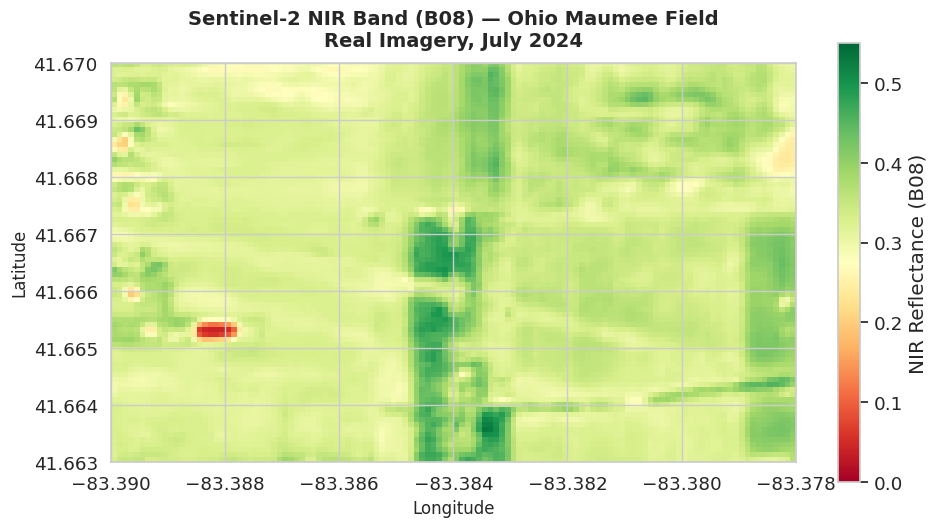

Saved: data/assignment-05/nir_band_B08.png
=== Red Band (B04) — Data Read Verification ===
Shape: (80, 120), Min: 0.0190, Max: 0.2773, Mean: 0.1182


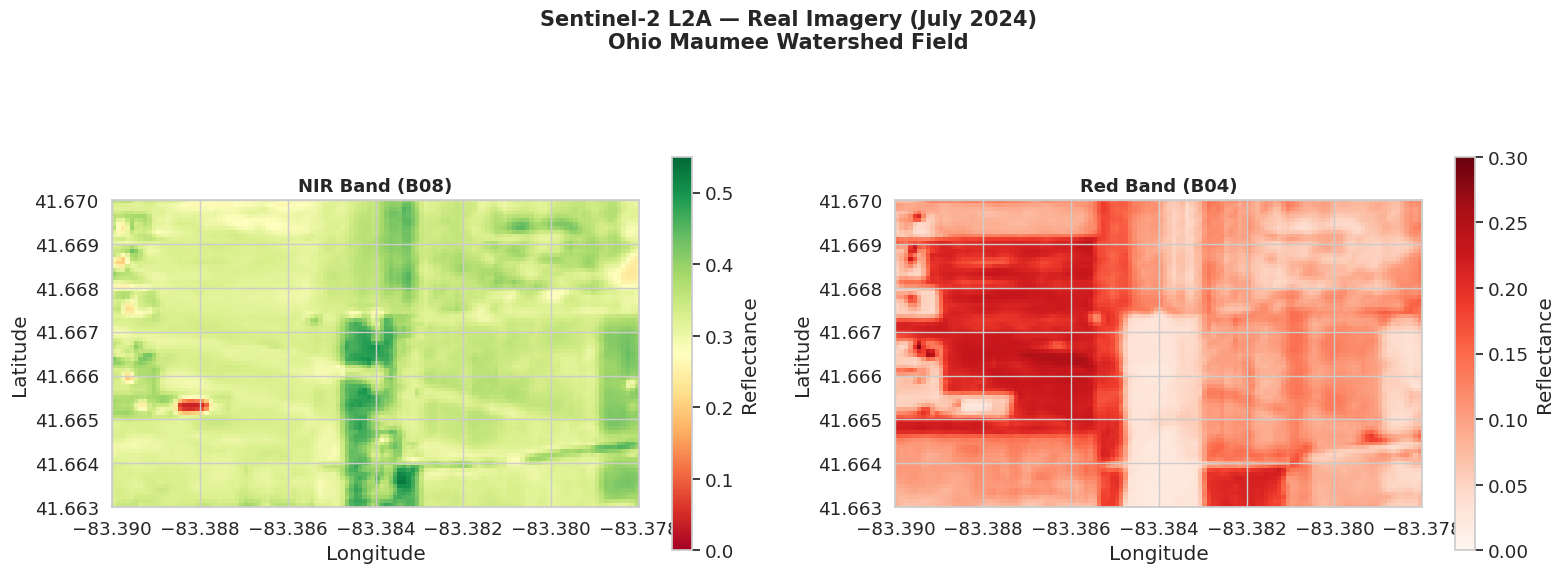

Saved: data/assignment-05/nir_red_comparison.png
=== data/assignment-05/ contents ===
  [OUTPUT] nir_band_B08.png                                 209,958 bytes
  [OUTPUT] nir_red_comparison.png                           312,481 bytes
  [INPUT ] sample_2_fields.geojson                            1,996 bytes
  [INPUT ] sample_aoi.geojson                                   772 bytes
  [INPUT ] sample_field_stats.csv                               618 bytes
  [INPUT ] sample_ndvi_metadata.json                          1,230 bytes
  [INPUT ] sample_ndvi_pixels.csv                               483 bytes
  [OUTPUT] sentinel2_B04_Red.tif                             27,443 bytes
  [OUTPUT] sentinel2_B08_NIR.tif                             25,396 bytes


In [6]:
# Cell 1 — Setup and imports
import os
import json
import shutil
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
# Load credentials from .env (gitignored — never committed)
load_dotenv()
os.makedirs('../data/assignment-05', exist_ok=True)
print('Setup complete.')
# Cell 2 — Copy skill example artifacts to data/assignment-05
skill_examples = '../.skills/ag-skills/sentinel2-imagery/examples'
field_examples = '../.skills/ag-skills/field-boundaries/examples'
artifacts = {
    f'{skill_examples}/sample_ndvi_metadata.json': '../data/assignment-05/sample_ndvi_metadata.json',
    f'{skill_examples}/sample_field_stats.csv': '../data/assignment-05/sample_field_stats.csv',
    f'{skill_examples}/sample_ndvi_pixels.csv': '../data/assignment-05/sample_ndvi_pixels.csv',
    f'{skill_examples}/sample_aoi.geojson': '../data/assignment-05/sample_aoi.geojson',
    f'{field_examples}/sample_2_fields.geojson': '../data/assignment-05/sample_2_fields.geojson',
}
for src, dst in artifacts.items():
    shutil.copy2(src, dst)
    print(f'Copied: {os.path.basename(dst)}')
# Cell 3 — Inspect skill example metadata
with open('../data/assignment-05/sample_ndvi_metadata.json') as f:
    metadata = json.load(f)
print('=== Sentinel-2 Scene Metadata (from skill example) ===')
print(f"Product:    {metadata['product_id']}")
print(f"Date:       {metadata['acquisition_date']}")
print(f"Platform:   {metadata['platform']}")
print(f"Resolution: {metadata['spatial_resolution']}m")
print(f"CRS:        {metadata['crs']}")
print(f"NDVI bands: {metadata['bands_used_for_ndvi']}")
print(f"Cloud:      {metadata['cloud_cover']}%")
# Cell 4 — Authenticate with Copernicus Data Space
client_id = os.environ['COPERNICUS_CLIENT_ID']
client_secret = os.environ['COPERNICUS_CLIENT_SECRET']
token_resp = requests.post(
    'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
    data={
        'grant_type': 'client_credentials',
        'client_id': client_id,
        'client_secret': client_secret,
    }
)
token = token_resp.json()['access_token']
print(f'Authenticated with Copernicus Data Space (token length: {len(token)})')
# Cell 5 — Define AOI from our Ohio Maumee field
# First field from ohio_maumee_20.geojson (field_id: 391623002240612)
# Small bbox around the field with buffer
bbox = [-83.39, 41.663, -83.378, 41.670]
print(f'AOI bbox: {bbox}')
print(f'  Longitude: {bbox[0]:.3f} to {bbox[2]:.3f}')
print(f'  Latitude:  {bbox[1]:.3f} to {bbox[3]:.3f}')
# Cell 6 — Download Red band (B04) via Sentinel Hub Process API
evalscript_b04 = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["B04"], units: "REFLECTANCE" }],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}
function evaluatePixel(sample) {
  return [sample.B04];
}
"""
request_body = {
    "input": {
        "bounds": {
            "bbox": bbox,
            "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}
        },
        "data": [{
            "type": "sentinel-2-l2a",
            "dataFilter": {
                "timeRange": {
                    "from": "2024-07-01T00:00:00Z",
                    "to": "2024-07-31T23:59:59Z"
                },
                "maxCloudCoverage": 30
            },
            "processing": {"upsampling": "BILINEAR"}
        }]
    },
    "output": {
        "width": 120,
        "height": 80,
        "responses": [{"identifier": "default", "format": {"type": "image/tiff"}}]
    },
    "evalscript": evalscript_b04
}
headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json",
    "Accept": "image/tiff"
}
print("Downloading B04 (Red band)...")
resp = requests.post("https://sh.dataspace.copernicus.eu/api/v1/process",
                     headers=headers, json=request_body)
print(f"  Status: {resp.status_code}, Size: {len(resp.content):,} bytes")
with open('../data/assignment-05/sentinel2_B04_Red.tif', 'wb') as f:
    f.write(resp.content)
print("  Saved: data/assignment-05/sentinel2_B04_Red.tif")
# Cell 7 — Download NIR band (B08) via Sentinel Hub Process API
evalscript_b08 = """
//VERSION=3
function setup() {
  return {
    input: [{ bands: ["B08"], units: "REFLECTANCE" }],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}
function evaluatePixel(sample) {
  return [sample.B08];
}
"""
request_body["evalscript"] = evalscript_b08
print("Downloading B08 (NIR band)...")
resp = requests.post("https://sh.dataspace.copernicus.eu/api/v1/process",
                     headers=headers, json=request_body)
print(f"  Status: {resp.status_code}, Size: {len(resp.content):,} bytes")
with open('../data/assignment-05/sentinel2_B08_NIR.tif', 'wb') as f:
    f.write(resp.content)
print("  Saved: data/assignment-05/sentinel2_B08_NIR.tif")
# Cell 8 — Read and display the NIR band (single-band output image)
with rasterio.open('../data/assignment-05/sentinel2_B08_NIR.tif') as src:
    nir_data = src.read(1)
    nir_bounds = src.bounds
    nir_crs = src.crs
print('=== NIR Band (B08) — Data Read Verification ===')
print(f'Shape:  {nir_data.shape} (height x width)')
print(f'Dtype:  {nir_data.dtype}')
print(f'CRS:    {nir_crs}')
print(f'Bounds: {nir_bounds}')
print(f'Min:    {nir_data.min():.4f}')
print(f'Max:    {nir_data.max():.4f}')
print(f'Mean:   {nir_data.mean():.4f}')
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(nir_data, cmap='RdYlGn', vmin=0.0, vmax=0.55,
               extent=[nir_bounds.left, nir_bounds.right,
                       nir_bounds.bottom, nir_bounds.top])
fig.colorbar(im, ax=ax, shrink=0.8, label='NIR Reflectance (B08)')
ax.set_title('Sentinel-2 NIR Band (B08) — Ohio Maumee Field\nReal Imagery, July 2024',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
fig.savefig('../data/assignment-05/nir_band_B08.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/assignment-05/nir_band_B08.png')
# Cell 9 — Read and display the Red band
with rasterio.open('../data/assignment-05/sentinel2_B04_Red.tif') as src:
    red_data = src.read(1)
    red_bounds = src.bounds
print('=== Red Band (B04) — Data Read Verification ===')
print(f'Shape: {red_data.shape}, Min: {red_data.min():.4f}, Max: {red_data.max():.4f}, Mean: {red_data.mean():.4f}')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# NIR
im1 = axes[0].imshow(nir_data, cmap='RdYlGn', vmin=0.0, vmax=0.55,
                      extent=[nir_bounds.left, nir_bounds.right,
                              nir_bounds.bottom, nir_bounds.top])
fig.colorbar(im1, ax=axes[0], shrink=0.8, label='Reflectance')
axes[0].set_title('NIR Band (B08)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
# Red
im2 = axes[1].imshow(red_data, cmap='Reds', vmin=0.0, vmax=0.3,
                      extent=[red_bounds.left, red_bounds.right,
                              red_bounds.bottom, red_bounds.top])
fig.colorbar(im2, ax=axes[1], shrink=0.8, label='Reflectance')
axes[1].set_title('Red Band (B04)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
fig.suptitle('Sentinel-2 L2A — Real Imagery (July 2024)\nOhio Maumee Watershed Field',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('../data/assignment-05/nir_red_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/assignment-05/nir_red_comparison.png')
# Cell 10 — Inventory of all artifacts
print('=== data/assignment-05/ contents ===')
for f in sorted(os.listdir('../data/assignment-05/')):
    size = os.path.getsize(f'../data/assignment-05/{f}')
    if f.endswith(('.tif', '.png')):
        label = 'OUTPUT'
    else:
        label = 'INPUT '
    print(f'  [{label}] {f:45s} {size:>10,} bytes')

## 4. Generate NDVI Image

**Formula:** NDVI = (NIR - Red) / (NIR + Red)

NDVI is calculated per-pixel from the satellite imagery, then summarized per field by computing zonal statistics (mean, median, std) within each field polygon.

=== NDVI Calculation ===
Shape:  (80, 120)
Min:    0.1078
Max:    0.9163
Mean:   0.4987
Median: 0.5187

Saved: data/assignment-05/sentinel2_NDVI.tif


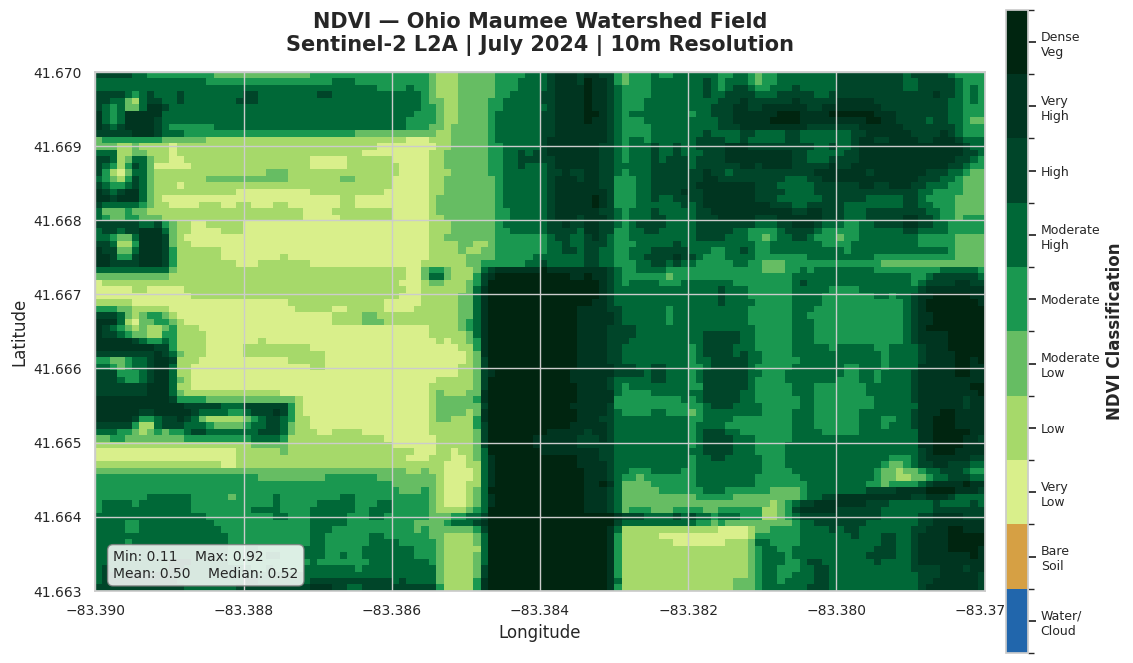

Saved: data/assignment-05/ndvi_map.png


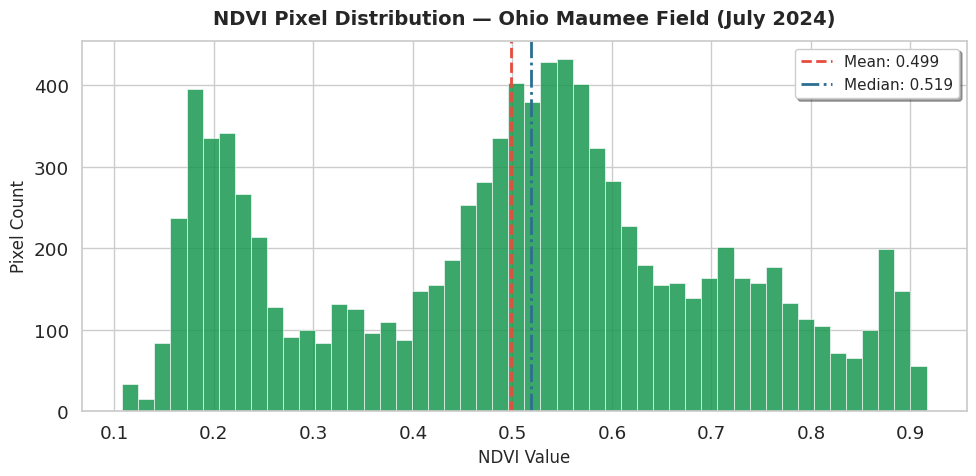

Saved: data/assignment-05/ndvi_histogram.png


In [7]:
# Cell 11 — Calculate NDVI from real Sentinel-2 bands
with rasterio.open('../data/assignment-05/sentinel2_B08_NIR.tif') as src:
    nir = src.read(1).astype('float32')
    profile = src.profile.copy()
    bounds = src.bounds
with rasterio.open('../data/assignment-05/sentinel2_B04_Red.tif') as src:
    red = src.read(1).astype('float32')
# NDVI = (NIR - Red) / (NIR + Red)
denominator = nir + red
ndvi = np.where(denominator > 0, (nir - red) / denominator, np.nan)
ndvi = ndvi.astype('float32')
print('=== NDVI Calculation ===')
print(f'Shape:  {ndvi.shape}')
print(f'Min:    {np.nanmin(ndvi):.4f}')
print(f'Max:    {np.nanmax(ndvi):.4f}')
print(f'Mean:   {np.nanmean(ndvi):.4f}')
print(f'Median: {np.nanmedian(ndvi):.4f}')
# Save NDVI as GeoTIFF
profile.update(dtype='float32', count=1, nodata=np.nan, compress='lzw')
with rasterio.open('../data/assignment-05/sentinel2_NDVI.tif', 'w', **profile) as dst:
    dst.write(ndvi, 1)
print('\nSaved: data/assignment-05/sentinel2_NDVI.tif')
# Cell 12 — NDVI map with professional styling
from matplotlib.colors import BoundaryNorm, ListedColormap
# Define NDVI classification
ndvi_classes = [-1.0, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
ndvi_labels = ['Water/\nCloud', 'Bare\nSoil', 'Very\nLow', 'Low', 'Moderate\nLow',
               'Moderate', 'Moderate\nHigh', 'High', 'Very\nHigh', 'Dense\nVeg']
ndvi_colors = ['#2166ac', '#d6a044', '#d9ef8b', '#a6d96a', '#66bd63',
               '#1a9850', '#006837', '#004529', '#003520', '#002510']
cmap = ListedColormap(ndvi_colors)
norm = BoundaryNorm(ndvi_classes, cmap.N)
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(ndvi, cmap=cmap, norm=norm,
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               interpolation='nearest')
# Colorbar with class labels
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02, aspect=30)
cbar.set_ticks([(ndvi_classes[i] + ndvi_classes[i+1]) / 2 for i in range(len(ndvi_labels))])
cbar.set_ticklabels(ndvi_labels, fontsize=9)
cbar.set_label('NDVI Classification', fontsize=12, fontweight='bold')
# Title and labels
ax.set_title('NDVI — Ohio Maumee Watershed Field\n'
             'Sentinel-2 L2A | July 2024 | 10m Resolution',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.tick_params(labelsize=10)
# Summary stats annotation
stats_text = (f'Min: {np.nanmin(ndvi):.2f}    Max: {np.nanmax(ndvi):.2f}\n'
              f'Mean: {np.nanmean(ndvi):.2f}    Median: {np.nanmedian(ndvi):.2f}')
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray'))
plt.tight_layout()
fig.savefig('../data/assignment-05/ndvi_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/assignment-05/ndvi_map.png')
# Cell 13 — NDVI histogram to show pixel distribution
fig, ax = plt.subplots(figsize=(10, 5))
valid_ndvi = ndvi[~np.isnan(ndvi)].flatten()
ax.hist(valid_ndvi, bins=50, color='#1a9850', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(np.mean(valid_ndvi), color='#E74C3C', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(valid_ndvi):.3f}')
ax.axvline(np.median(valid_ndvi), color='#2C6E91', linestyle='-.', linewidth=2,
           label=f'Median: {np.median(valid_ndvi):.3f}')
ax.set_title('NDVI Pixel Distribution — Ohio Maumee Field (July 2024)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('NDVI Value', fontsize=12)
ax.set_ylabel('Pixel Count', fontsize=12)
ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
fig.savefig('../data/assignment-05/ndvi_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/assignment-05/ndvi_histogram.png')
